In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns

In [ ]:
df = pd.read_csv('/content/credit_risk_dataset.csv')

In [ ]:
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [ ]:
df.tail()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
32576,57,53000,MORTGAGE,1.0,PERSONAL,C,5800,13.16,0,0.11,N,30
32577,54,120000,MORTGAGE,4.0,PERSONAL,A,17625,7.49,0,0.15,N,19
32578,65,76000,RENT,3.0,HOMEIMPROVEMENT,B,35000,10.99,1,0.46,N,28
32579,56,150000,MORTGAGE,5.0,PERSONAL,B,15000,11.48,0,0.10,N,26
32580,66,42000,RENT,2.0,MEDICAL,B,6475,9.99,0,0.15,N,30


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


In [ ]:
df.isna().sum()

,0
person_age,0
person_income,0
person_home_ownership,0
person_emp_length,895
loan_intent,0
loan_grade,0
loan_amnt,0
loan_int_rate,3116
loan_status,0
loan_percent_income,0


In [ ]:
df.duplicated().sum()

np.int64(165)

In [ ]:
df = df.drop_duplicates()

In [ ]:
df.shape

(32416, 12)

In [ ]:
df['person_emp_length'] = df['person_emp_length'].fillna(
    df['person_emp_length'].median())

In [ ]:
df.isna().sum()

,0
person_age,0
person_income,0
person_home_ownership,0
person_emp_length,0
loan_intent,0
loan_grade,0
loan_amnt,0
loan_int_rate,3095
loan_status,0
loan_percent_income,0


In [ ]:
df['loan_int_rate'].isnull().sum()

np.int64(3095)

In [ ]:
df.groupby('loan_grade')['loan_int_rate'].median()

,loan_int_rate
loan_grade,
A,7.490
B,10.990
C,13.480
D,15.310
E,16.820
F,18.535
G,20.160


In [ ]:
# Create missing indicator
df['loan_int_missing'] = df['loan_int_rate'].isnull().astype(int)

# Group-wise median imputation
df['loan_int_rate'] = df.groupby('loan_grade')['loan_int_rate'] \
                        .transform(lambda x: x.fillna(x.median()))

In [ ]:
df['loan_int_rate'].isnull().sum()

np.int64(0)

In [ ]:
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,loan_int_missing
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3,0
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2,0
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3,0
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2,0
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4,0


In [ ]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
cat_cols = df.select_dtypes(include=['object']).columns

print("Numerical Columns:")
print(num_cols)

print("\nCategorical Columns:")
print(cat_cols)

Numerical Columns:
Index(['person_age', 'person_income', 'person_emp_length', 'loan_amnt',
       'loan_int_rate', 'loan_status', 'loan_percent_income',
       'cb_person_cred_hist_length', 'loan_int_missing'],
      dtype='object')

Categorical Columns:
Index(['person_home_ownership', 'loan_intent', 'loan_grade',
       'cb_person_default_on_file'],
      dtype='object')


In [ ]:
numerical_cols = df[num_cols]
categorical_cols = df[cat_cols]

In [ ]:
numerical_cols.head()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length,loan_int_missing
0,22,59000,123.0,35000,16.02,1,0.59,3,0
1,21,9600,5.0,1000,11.14,0,0.10,2,0
2,25,9600,1.0,5500,12.87,1,0.57,3,0
3,23,65500,4.0,35000,15.23,1,0.53,2,0
4,24,54400,8.0,35000,14.27,1,0.55,4,0


In [ ]:
df['person_emp_length'].describe()

,person_emp_length
count,32416.000000
mean,4.768880
std,4.090411
min,0.000000
25%,2.000000
50%,4.000000
75%,7.000000
max,123.000000


In [ ]:
df = df.drop(columns=['loan_int_missing'])

<Axes: xlabel='person_emp_length'>

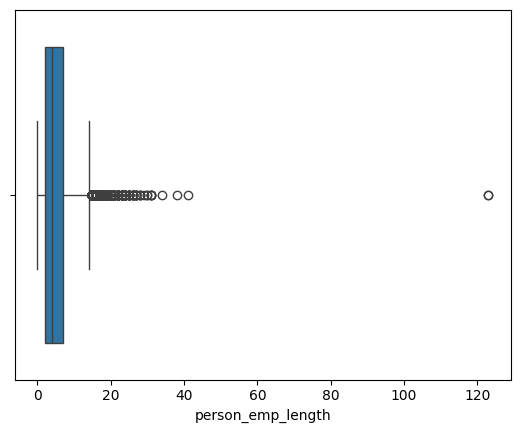

In [ ]:
sns.boxplot(x=df['person_emp_length'])

In [ ]:
df.loc[df['person_emp_length'] > 60, 'person_emp_length'] = pd.NA

median_emp = df['person_emp_length'].median()

df['person_emp_length'] = df['person_emp_length'].fillna(median_emp)

In [ ]:
import numpy as np

df['person_income'] = np.log1p(df['person_income'])

<Axes: xlabel='person_emp_length'>

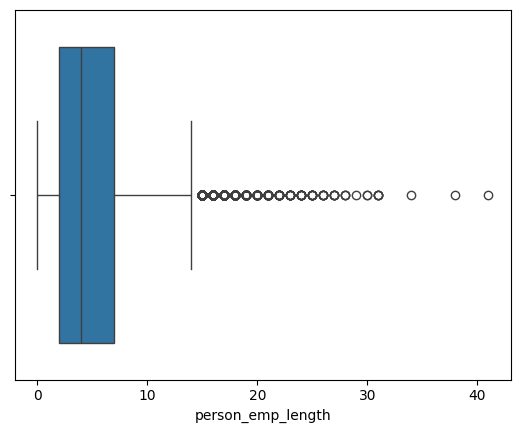

In [ ]:
sns.boxplot(x=df['person_emp_length'])

In [ ]:
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,10.985310,RENT,4.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9.169623,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9.169623,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,11.089821,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,10.904138,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


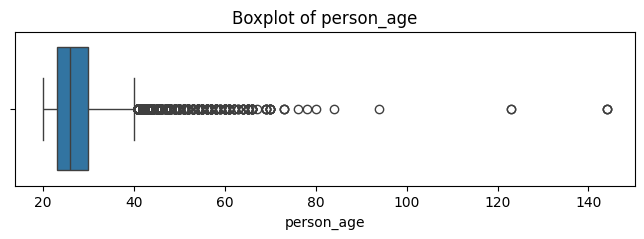

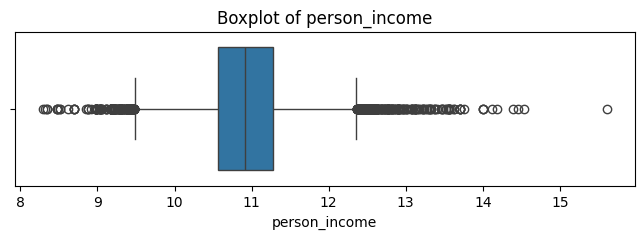

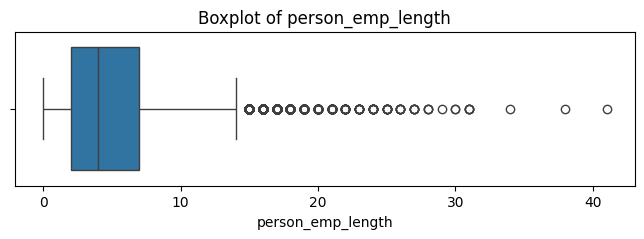

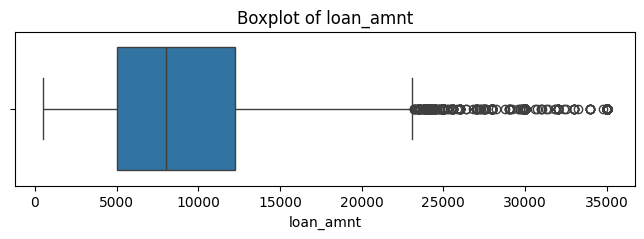

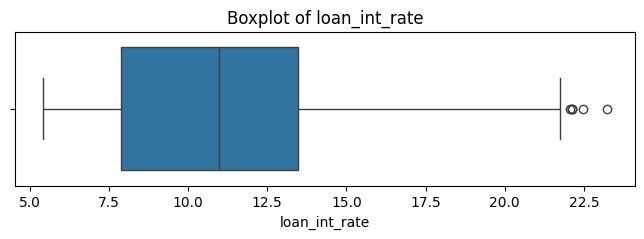

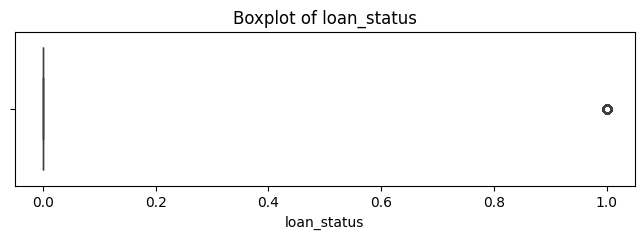

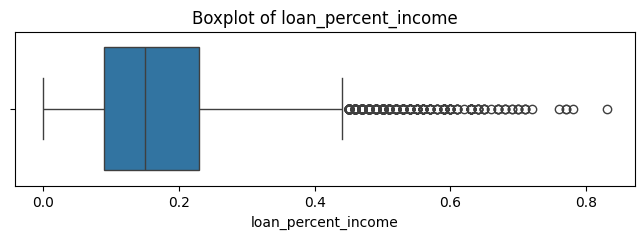

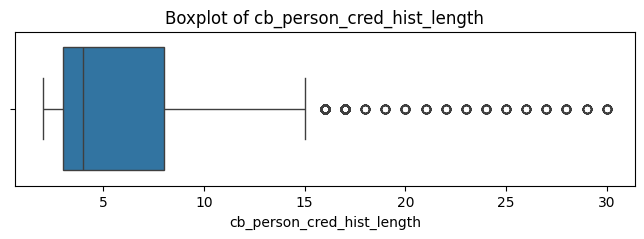

In [ ]:
import matplotlib.pyplot as plt

# Re-define num_cols to reflect the current state of df
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in num_cols:

    plt.figure(figsize=(8,2))

    sns.boxplot(x=df[col]) # Corrected: Pass the actual Series data

    plt.title(f'Boxplot of {col}') # Corrected: Use an f-string for the title

    plt.show()

In [ ]:
# Replace impossible ages (>80) with NaN
df.loc[df['person_age'] > 80, 'person_age'] = pd.NA

# Calculate median age from valid values
median_age = df['person_age'].median()

# Fill missing values with median
df['person_age'] = df['person_age'].fillna(median_age)

# Convert to integer
df['person_age'] = df['person_age'].round().astype(int)

<Axes: xlabel='person_age'>

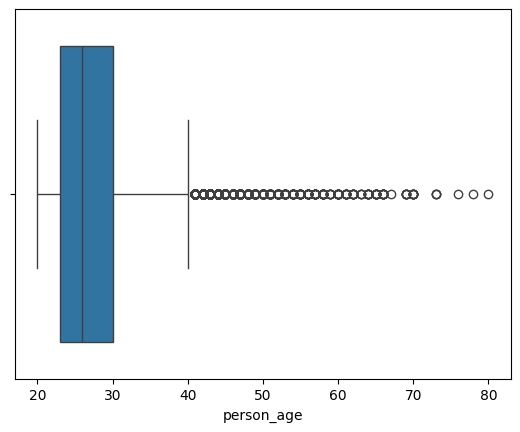

In [ ]:
sns.boxplot(x=df['person_age'])

In [ ]:
df['loan_status'].dtype

dtype('int64')

In [ ]:
df['loan_status'].value_counts()

,count
loan_status,
0,25327
1,7089


In [ ]:
df['cb_person_default_on_file'] = df['cb_person_default_on_file'].map({
    'N':0,
    'Y':1
})

In [ ]:
grade_map = {
    'A':1,
    'B':2,
    'C':3,
    'D':4,
    'E':5,
    'F':6,
    'G':7

}

df['loan_grade'] = df['loan_grade'].map(grade_map)

In [ ]:
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,10.985310,RENT,4.0,PERSONAL,4,35000,16.02,1,0.59,1,3
1,21,9.169623,OWN,5.0,EDUCATION,2,1000,11.14,0,0.10,0,2
2,25,9.169623,MORTGAGE,1.0,MEDICAL,3,5500,12.87,1,0.57,0,3
3,23,11.089821,RENT,4.0,MEDICAL,3,35000,15.23,1,0.53,0,2
4,24,10.904138,RENT,8.0,MEDICAL,3,35000,14.27,1,0.55,1,4


In [ ]:
df = pd.get_dummies(
    df,
    columns=[
        'person_home_ownership',
        'loan_intent'
    ],
    drop_first=True
)

In [ ]:
df.shape

(32416, 18)

In [ ]:
df.head()

,person_age,person_income,person_emp_length,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,person_home_ownership_OTHER,person_home_ownership_OWN,person_home_ownership_RENT,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE
0,22,10.985310,4.0,4,35000,16.02,1,0.59,1,3,False,False,True,False,False,False,True,False
1,21,9.169623,5.0,2,1000,11.14,0,0.10,0,2,False,True,False,True,False,False,False,False
2,25,9.169623,1.0,3,5500,12.87,1,0.57,0,3,False,False,False,False,False,True,False,False
3,23,11.089821,4.0,3,35000,15.23,1,0.53,0,2,False,False,True,False,False,True,False,False
4,24,10.904138,8.0,3,35000,14.27,1,0.55,1,4,False,False,True,False,False,True,False,False


In [ ]:
bool_cols = df.select_dtypes(include='bool').columns

df[bool_cols] = df[bool_cols].astype(int)

In [ ]:
df.head()

,person_age,person_income,person_emp_length,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,person_home_ownership_OTHER,person_home_ownership_OWN,person_home_ownership_RENT,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE
0,22,10.985310,4.0,4,35000,16.02,1,0.59,1,3,0,0,1,0,0,0,1,0
1,21,9.169623,5.0,2,1000,11.14,0,0.10,0,2,0,1,0,1,0,0,0,0
2,25,9.169623,1.0,3,5500,12.87,1,0.57,0,3,0,0,0,0,0,1,0,0
3,23,11.089821,4.0,3,35000,15.23,1,0.53,0,2,0,0,1,0,0,1,0,0
4,24,10.904138,8.0,3,35000,14.27,1,0.55,1,4,0,0,1,0,0,1,0,0


In [ ]:
X = df.drop(columns=['loan_status'])
y = df['loan_status']

In [ ]:
X.shape

(32416, 17)

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

In [ ]:
vif_data = pd.DataFrame()

vif_data['Feature'] = X.columns

vif_data['VIF'] = [
    variance_inflation_factor(X.values, i)
    for i in range(X.shape[1])
]

print(vif_data)

                        Feature         VIF
0                    person_age   91.008587
1                 person_income   79.823580
2             person_emp_length    2.700463
3                    loan_grade   39.951513
4                     loan_amnt    6.152799
5                 loan_int_rate  104.448237
6           loan_percent_income    5.951202
7     cb_person_default_on_file    1.710029
8    cb_person_cred_hist_length   13.033449
9   person_home_ownership_OTHER    1.010384
10    person_home_ownership_OWN    1.250348
11   person_home_ownership_RENT    2.585318
12        loan_intent_EDUCATION    2.248799
13  loan_intent_HOMEIMPROVEMENT    1.713834
14          loan_intent_MEDICAL    2.168131
15         loan_intent_PERSONAL    2.068495
16          loan_intent_VENTURE    2.128997


In [ ]:
df[['person_age', 'cb_person_cred_hist_length']].corr()

,person_age,cb_person_cred_hist_length
person_age,1.000000,0.877486
cb_person_cred_hist_length,0.877486,1.000000


In [ ]:
num_cols = df[['person_age','person_income','person_emp_length','loan_amnt','loan_int_rate','loan_percent_income','cb_person_cred_hist_length']]

In [ ]:
vif_data = pd.DataFrame()

vif_data['Feature'] = num_cols.columns

vif_data['VIF'] = [
    variance_inflation_factor(num_cols.values, i)
    for i in range(num_cols.shape[1])
]

print(vif_data)

                      Feature        VIF
0                  person_age  90.510832
1               person_income  60.140331
2           person_emp_length   2.599354
3                   loan_amnt   5.556879
4               loan_int_rate  12.830499
5         loan_percent_income   5.377006
6  cb_person_cred_hist_length  13.021800


In [ ]:
X = X.drop(columns=['person_age'],axis=1)

In [ ]:
X = X.drop(columns=['loan_amnt', 'loan_grade'])

In [ ]:
X.head()

,person_income,person_emp_length,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,person_home_ownership_OTHER,person_home_ownership_OWN,person_home_ownership_RENT,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE
0,10.985310,4.0,16.02,0.59,1,3,0,0,1,0,0,0,1,0
1,9.169623,5.0,11.14,0.10,0,2,0,1,0,1,0,0,0,0
2,9.169623,1.0,12.87,0.57,0,3,0,0,0,0,0,1,0,0
3,11.089821,4.0,15.23,0.53,0,2,0,0,1,0,0,1,0,0
4,10.904138,8.0,14.27,0.55,1,4,0,0,1,0,0,1,0,0


In [ ]:
# Select ONLY continuous numerical columns
num_cols = [
    'person_income',
    'person_emp_length',
    'loan_int_rate',
    'loan_percent_income',
    'cb_person_cred_hist_length'
]

# Create dataframe with only numerical columns
X_num = df[num_cols]

# Create VIF dataframe
vif_data = pd.DataFrame()

vif_data['Feature'] = X_num.columns

vif_data['VIF'] = [
    variance_inflation_factor(X_num.values, i)
    for i in range(X_num.shape[1])
]

print(vif_data)

                      Feature        VIF
0               person_income  16.819846
1           person_emp_length   2.549336
2               loan_int_rate  12.813062
3         loan_percent_income   3.446161
4  cb_person_cred_hist_length   3.134277


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
scaler = StandardScaler()

num_cols = [
    'person_income',
    'person_emp_length',
    'loan_int_rate',
    'loan_percent_income',
    'cb_person_cred_hist_length'
]

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])

X_test[num_cols] = scaler.transform(X_test[num_cols])

In [ ]:
model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
y_prob = model.predict_proba(X_test)[:,1]

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[4811  262]
 [ 724  687]]


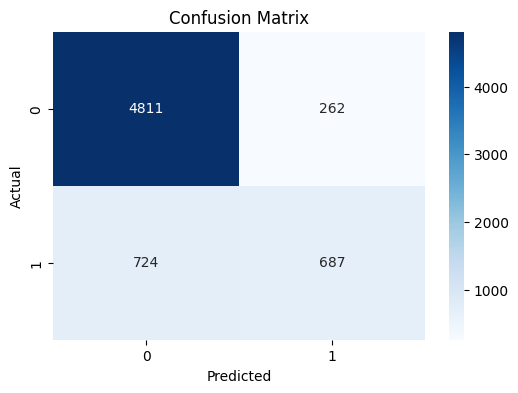

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.title('Confusion Matrix')

plt.show()

In [ ]:
from sklearn.metrics import f1_score

f1 = f1_score(y_test, y_pred)

print("F1 Score:", f1)

F1 Score: 0.5822033898305085


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.87      0.95      0.91      5073
           1       0.72      0.49      0.58      1411

    accuracy                           0.85      6484
   macro avg       0.80      0.72      0.74      6484
weighted avg       0.84      0.85      0.84      6484



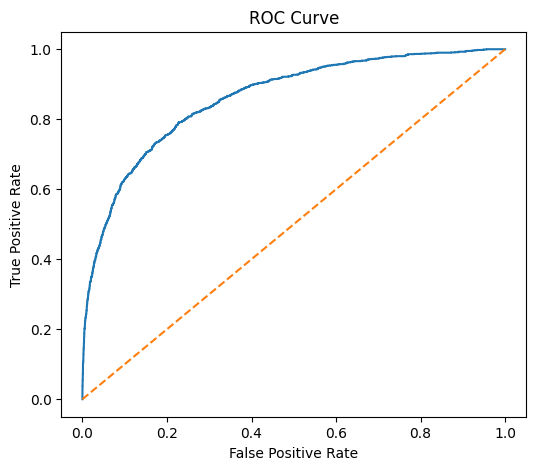

In [ ]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(6,5))

plt.plot(fpr, tpr)

plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

plt.title('ROC Curve')

plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


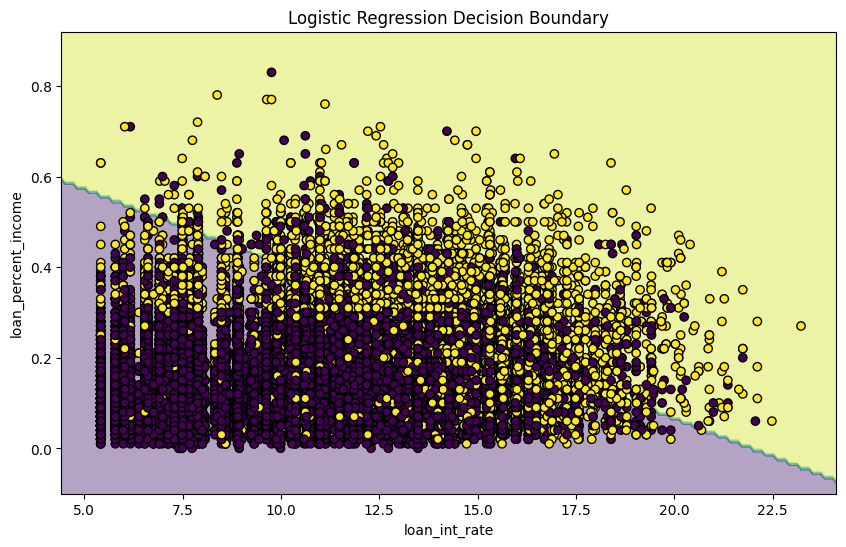

In [ ]:
X_plot = df[['loan_int_rate', 'loan_percent_income']]
y_plot = df['loan_status']

# Train model
log_model = LogisticRegression()

log_model.fit(X_plot, y_plot)

# Meshgrid
x_min, x_max = X_plot.iloc[:,0].min()-1, X_plot.iloc[:,0].max()+1
y_min, y_max = X_plot.iloc[:,1].min()-0.1, X_plot.iloc[:,1].max()+0.1

xx, yy = np.meshgrid(
    np.arange(x_min, x_max, 0.1),
    np.arange(y_min, y_max, 0.01)
)

# Predictions
Z = log_model.predict(
    np.c_[xx.ravel(), yy.ravel()]
)

Z = Z.reshape(xx.shape)

# Plot
plt.figure(figsize=(10,6))

plt.contourf(xx, yy, Z, alpha=0.4)

plt.scatter(
    X_plot.iloc[:,0],
    X_plot.iloc[:,1],
    c=y_plot,
    edgecolor='k'
)

plt.xlabel('loan_int_rate')
plt.ylabel('loan_percent_income')

plt.title('Logistic Regression Decision Boundary')

plt.show()

In [ ]:
from sklearn.tree import DecisionTreeClassifier

tree_model = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

tree_model.fit(X_train, y_train)

y_pred_tree = tree_model.predict(X_test)

In [ ]:
from sklearn.metrics import classification_report, f1_score

print(classification_report(y_test, y_pred_tree))

print("F1 Score:", f1_score(y_test, y_pred_tree))

              precision    recall  f1-score   support

           0       0.90      0.99      0.94      5073
           1       0.93      0.60      0.72      1411

    accuracy                           0.90      6484
   macro avg       0.91      0.79      0.83      6484
weighted avg       0.90      0.90      0.89      6484

F1 Score: 0.7244501940491591


In [ ]:
print("Train Accuracy:", tree_model.score(X_train, y_train))

print("Test Accuracy:", tree_model.score(X_test, y_test))

Train Accuracy: 0.9024757056918093
Test Accuracy: 0.9014497223935842


In [ ]:
from sklearn.svm import SVC

# Create model
svm_model = SVC()

# Train model
svm_model.fit(X_train, y_train)

# Predictions
y_pred_svm = svm_model.predict(X_test)

# F1 Score
print("F1 Score:", f1_score(y_test, y_pred_svm))

# Full Report
print(classification_report(y_test, y_pred_svm))

F1 Score: 0.728806410797132
              precision    recall  f1-score   support

           0       0.90      0.98      0.94      5073
           1       0.90      0.61      0.73      1411

    accuracy                           0.90      6484
   macro avg       0.90      0.80      0.83      6484
weighted avg       0.90      0.90      0.89      6484



In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report

# Create model
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    random_state=42
)

# Train model
rf_model.fit(X_train, y_train)

# Predictions
y_pred_rf = rf_model.predict(X_test)

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred_rf))

# F1 Score
print("F1 Score:", f1_score(y_test, y_pred_rf))

# Full Report
print(classification_report(y_test, y_pred_rf))

Accuracy: 0.8946637877853177
F1 Score: 0.6902494331065759
              precision    recall  f1-score   support

           0       0.89      0.99      0.94      5073
           1       0.96      0.54      0.69      1411

    accuracy                           0.89      6484
   macro avg       0.92      0.77      0.81      6484
weighted avg       0.90      0.89      0.88      6484



In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report

# Create model
xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    random_state=42
)

# Train model
xgb_model.fit(X_train, y_train)

# Predictions
y_pred_xgb = xgb_model.predict(X_test)

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred_xgb))

# F1 Score
print("F1 Score:", f1_score(y_test, y_pred_xgb))

# Full Report
print(classification_report(y_test, y_pred_xgb))


Accuracy: 0.9236582356570019
F1 Score: 0.7977114834491214
              precision    recall  f1-score   support

           0       0.92      0.99      0.95      5073
           1       0.94      0.69      0.80      1411

    accuracy                           0.92      6484
   macro avg       0.93      0.84      0.88      6484
weighted avg       0.92      0.92      0.92      6484



In [ ]:
from sklearn.model_selection import GridSearchCV

rf_model = RandomForestClassifier(random_state=42)

param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [5, 10, 15],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

grid_search = GridSearchCV(
    estimator=rf_model,
    param_grid=param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:")
print(grid_search.best_params_)

print("Best F1 Score:")
print(grid_search.best_score_)

Best Parameters:
{'max_depth': 15, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 50}
Best F1 Score:
0.7903918215854315


In [ ]:
best_rf = grid_search.best_estimator_

In [ ]:
y_pred_rf = best_rf.predict(X_test)

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred_rf))

print("F1 Score:", f1_score(y_test, y_pred_rf))

Accuracy: 0.9204194941394201
F1 Score: 0.7892156862745098


In [ ]:
# Base model
from sklearn.model_selection import RandomizedSearchCV

xgb_model = XGBClassifier(
    random_state=42,
    eval_metric='logloss'
)

# Hyperparameter space
param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7, 10],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0]
}

# Random Search
random_search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_dist,
    n_iter=20,
    cv=5,
    scoring='f1',
    random_state=42,
    n_jobs=-1
)

# Train
random_search.fit(X_train, y_train)

# Best parameters
print("Best Parameters:")
print(random_search.best_params_)

# Best model
best_xgb = random_search.best_estimator_

# Predictions
y_pred_xgb = best_xgb.predict(X_test)

# Evaluation
print("\nAccuracy:", accuracy_score(y_test, y_pred_xgb))

print("F1 Score:", f1_score(y_test, y_pred_xgb))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb))

Best Parameters:
{'subsample': 1.0, 'n_estimators': 200, 'max_depth': 7, 'learning_rate': 0.2, 'colsample_bytree': 0.8}

Accuracy: 0.9275138803207896
F1 Score: 0.812150279776179

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.99      0.96      5073
           1       0.93      0.72      0.81      1411

    accuracy                           0.93      6484
   macro avg       0.93      0.85      0.88      6484
weighted avg       0.93      0.93      0.92      6484

